In [3]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
from tabulate import tabulate
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost as xgb # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram


#--- Custom Functions as defined by the user ---
import sys
sys.path.append(os.path.abspath("../tools"))
import functions


In [4]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/Treetest2.csv") 
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))



Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering/xgboost
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Irrigation.mm_clean', 'irrigation_applied', 'harvest_date_clean', 'harvest_dayofyear', 'harves

/tmp/ipykernel_60350/3017083189.py:4: DtypeWarning: Columns (6,7,12,13,14,15,16,17,20,22,23,24,26,28,29,30,31,32,39,40,42,43,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/Treetest2.csv")


#### Define data summary function and Choose which cols to drop

In [4]:
functions.summarize_dataframe(df)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Grain.yield..tons.ha.1.                               | float64 |   69430 |          100   |      14855 |
| Trans5                                                | float64 |   69430 |          100   |       1068 |
| pre8                                                  | float64 |   69428 |          100   |        632 |
| pre9                                                  | float64 |   69428 |          100   |        639 |
| Evap8                                                 | float64 |   69430 |          100   |        565 |
| Evap7                                                 | float64 |   69430 |          100   |        565 |
| Evap6                                                 | float64 |   69430 |          100   |        565 |
| Evap5                     

In [5]:
# Define groups of columns to drop
LOCATION_COLS = [
    # "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.", "group",
    "Location.source", "X", "Y", "unit_code", "Year_x",
    # "latitude_jittered","longitude_jittered", "jitter_radius_km", "group_id"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week","dryspells(5days)", "drydays(annualsum)",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = [
    "gdp", "hdi", "irr_start_date", "Crop.variety",
    "rainfed_start_date",
    "Mean.annual.precipitation..mm.", "irrigation_applied", "Sand", 
    "Irrigation.mm_clean", "Mean.annual.temperature..Â.C.", "Irrigation.mm_clean", "Wheat.Type", 
]


# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (69430, 168)
Shape after dropping: (69430, 139)
Dropped columns: ['Pest.severity.score.......66', 'rainfed_end_date', 'Planting.date', 'Planting.date.1', 'irrigation_applied', 'Longitude..E.W.', 'end_date', 'Sand', 'Planting_Month', 'Harvesting.date.1', 'Planting_Week', 'Latitude..N.S.', 'Irrigation..mm.', 'Location.source', 'Irrigation.mm_clean', 'irr_start_date', 'harvest_month', 'Mean.annual.temperature..Â.C.', 'Mean.annual.precipitation..mm.', 'harvest_date_clean', 'Crop.variety', 'rainfed_start_date', 'irr_end_date', 'Treatment.type', 'harvest_week', 'Emissions..yes.no.', 'Wheat.Type', 'gdp', 'hdi']
Remaining columns: ['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Observation.period', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Water.regime', 'Soil.type', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Pest.prescence.

In [7]:
functions.summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Grain.yield..tons.ha.1.                               | float64 |   69430 |          100   |      14855 |
| Evap1                                                 | float64 |   69430 |          100   |        565 |
| EvapS2                                                | float64 |   69430 |          100   |       1155 |
| EvapS3                                                | float64 |   69430 |          100   |       1155 |
| EvapS4                                                | float64 |   69430 |          100   |       1146 |
| EvapS6                                                | float64 |   69430 |          100   |       1135 |
| EvapS9                                                | float64 |   69430 |          100   |       1153 |
| Trans2                    

#### For experimenting with different geographical ranges 

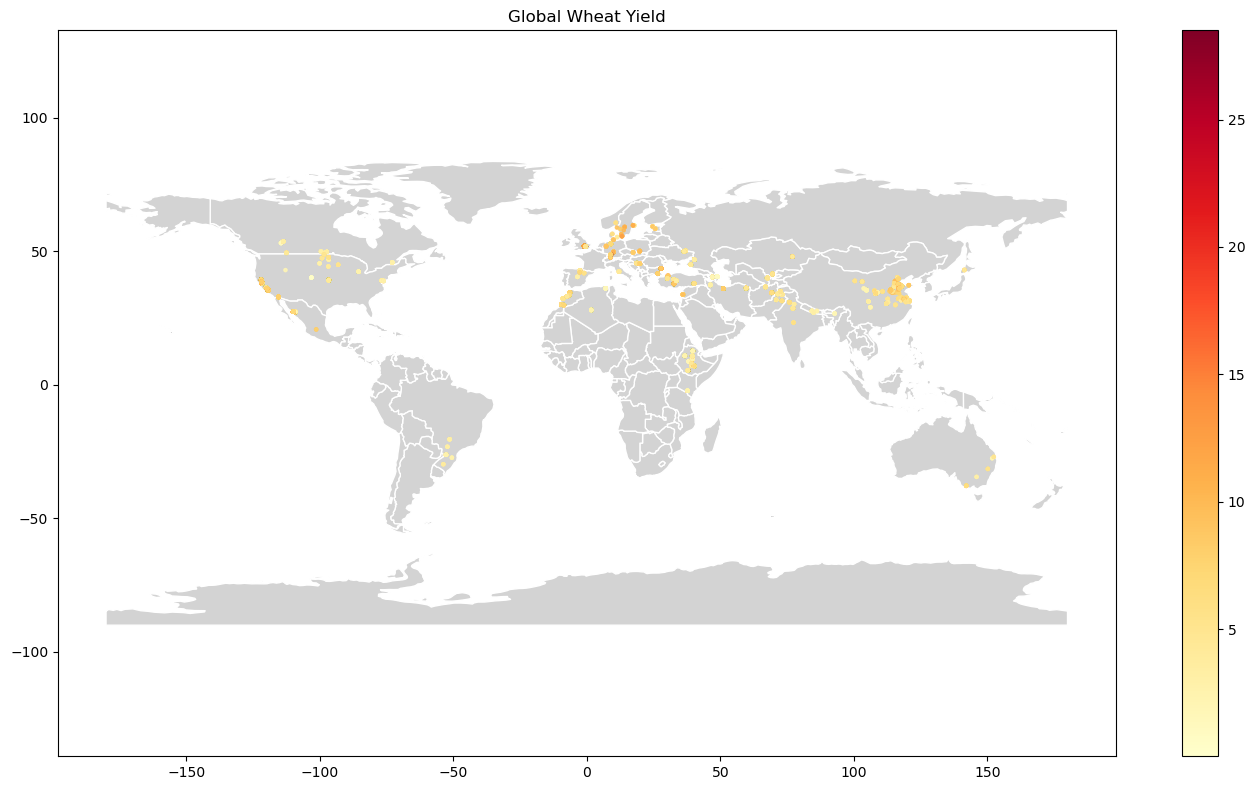

In [6]:
# Plotting the yield by region using the full DataFrame

functions.plot_yield_by_region(
    df=df_cleaned,
    coord_cols={
        'lat': 'Conversion.for.latitude',
        'lon': 'Conversion.for.longitude'
    },
    yield_col='Grain.yield..tons.ha.1.',
    bounds=None,  # or use a dict with min/max lat/lon
    title="Global Wheat Yield"
)

Play around with bounding boxes here

In [40]:
# Approximate bounding box for desired region (Europe, North Africa, America)
combined_bounds = {
    'min_lat': 20,     # Southern tip of South America
    'max_lat': 90,      # Northern Europe
    'min_lon': -30,    # Westernmost Alaska
    'max_lon': 45       # Eastern edge of Europe
}



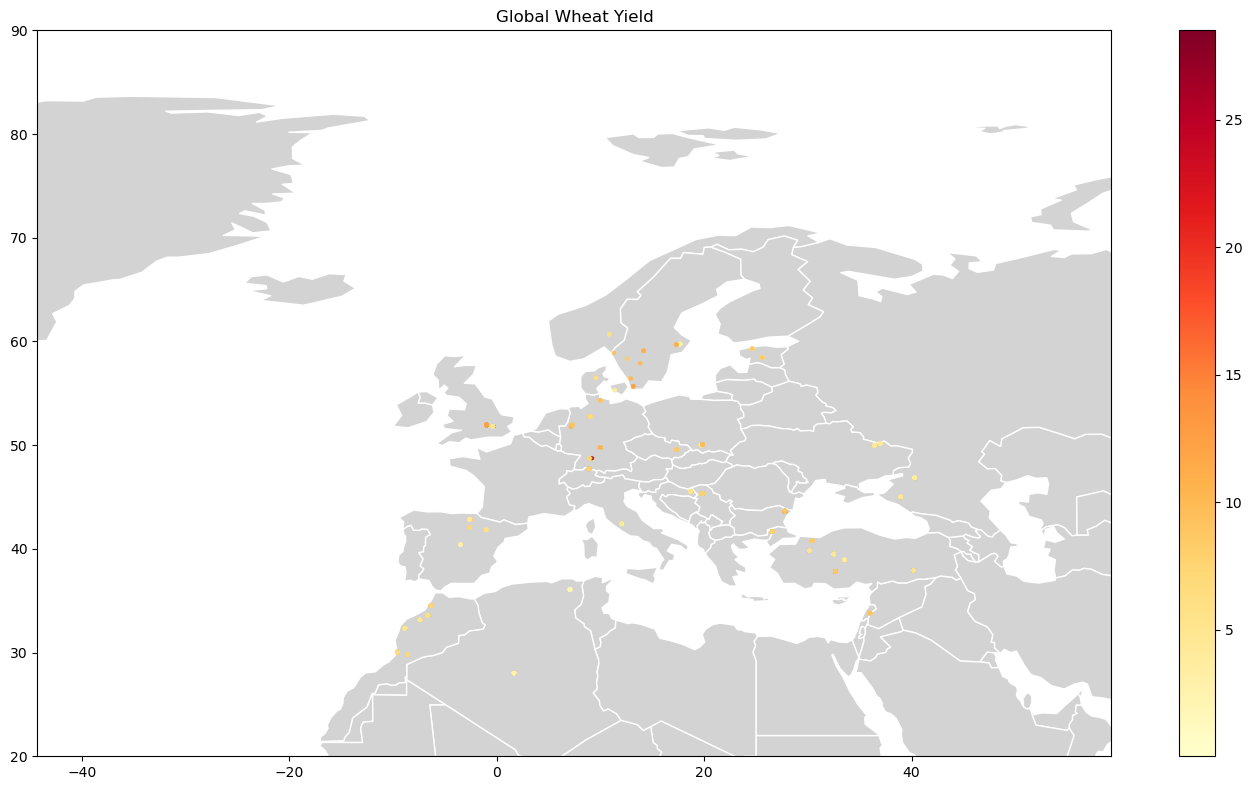

In [41]:
functions.plot_yield_by_region(
    df=df_cleaned,
    coord_cols={
        'lat': 'Conversion.for.latitude',
        'lon': 'Conversion.for.longitude'
    },
    yield_col='Grain.yield..tons.ha.1.',
    bounds=combined_bounds,  # or use a dict with min/max lat/lon
    title="Global Wheat Yield"
)

In [44]:
coord_cols = {
    'lat': 'Conversion.for.latitude',
    'lon': 'Conversion.for.longitude'
}

yield_col = 'Grain.yield..tons.ha.1.'

mask = functions.make_bounds_mask(df_cleaned, coord_cols, yield_col, combined_bounds)
df_cleaned = df_cleaned[mask].copy()

In [20]:
print(df_cleaned["Country"].value_counts())


Country
United States of America    36330
Mexico                      14237
Kenya                        7053
Ethiopia                     3909
United Kingdom               2481
China                        1118
Turkey                        851
Iran                          388
Morocco                       384
Germany                       285
Uzbekistan                    272
Russia                        228
Afghanistan                   194
Algeria                       184
Pakistan                      164
Ukraine                       158
Azerbaijan                    154
Canada                        132
Bulgaria                      118
Croatia                       114
India                          90
Sweden                         82
Serbia                         78
Brazil                         64
Kazakhstan                     50
Poland                         48
Spain                          44
Nepal                          42
Lebanon                        40
Estoni

In [21]:
functions.summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| temp3                                                 | float64 |   69430 |          100   |        275 |
| Location                                              | object  |   69430 |          100   |        231 |
| temp6                                                 | float64 |   69430 |          100   |        282 |
| temp7                                                 | float64 |   69430 |          100   |        281 |
| temp8                                                 | float64 |   69430 |          100   |        282 |
| temp9                                                 | float64 |   69430 |          100   |        282 |
| prc1                      

#### Preperation for modelling begins here

In [7]:
#see how many labels there are before doing rf: 
df_cleaned.select_dtypes(include="object").nunique().sort_values(ascending=False)


group_id                        572
Location                        231
State.Region.County.Province    132
Data.ID                          51
Soil.type                        48
Country                          37
Tillage.type                     19
Treatment_Category               14
Continent                         6
Treatment                         2
Pest.prescence....64              2
dtype: int64

End of Georange specification 

In [24]:
functions.summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| temp3                                                 | float64 |   69430 |          100   |        275 |
| Location                                              | object  |   69430 |          100   |        231 |
| temp6                                                 | float64 |   69430 |          100   |        282 |
| temp7                                                 | float64 |   69430 |          100   |        281 |
| temp8                                                 | float64 |   69430 |          100   |        282 |
| temp9                                                 | float64 |   69430 |          100   |        282 |
| prc1                      

### Onehot encode and prepare data

In [8]:
# Start fresh
X = df_cleaned.copy()
y = X.pop("Grain.yield..tons.ha.1.")

# Add spatial coordinates
X["lon"] = df_cleaned["Conversion.for.longitude"]
X["lat"] = df_cleaned["Conversion.for.latitude"]

# Identify categorical columns
object_cols = X.select_dtypes(include="object").columns.tolist()

# One-hot encode all categorical features (no LabelEncoder needed)
X_encoded = pd.get_dummies(X, columns=object_cols, drop_first=False)

# Ensure all features are numeric (XGBoost-friendly)
X_encoded = X_encoded.astype(float)

# Optional: make all columns visible in output
pd.set_option('display.max_columns', None)

X_encoded.head()

,id,Conversion.for.latitude,Conversion.for.longitude,Observation.period,N.rate..kg.N.ha.1.,P.rate..kg.P.ha.1.,start_date,harvest_dayofyear,year,dryspells.5days.,drydays.annualsum.,Agricultural_Use_._Fungicides_and_Bactericides_.t.,Agricultural_Use_._Herbicides_.t.,Agricultural_Use_._Insecticides_.t.,Agricultural_Use_._Other_Pesticides_nes_.t.,Agricultural_Use_._Pesticides_.total._.t.,Agricultural_Use_._Rodenticides_.t.,Use_per_area_of_cropland_._Pesticides_.total._.kg.ha.,gdp_per_capita,jitter_radius_km,latitude_jittered,longitude_jittered,prc1,prc2,prc3,prc4,prc5,prc6,prc7,prc8,prc9,NDVI1,NDVI2,NDVI3,NDVI4,NDVI5,NDVI6,NDVI7,NDVI8,NDVI9,Evap1,Evap2,Evap3,Evap4,Evap5,Evap6,Evap7,Evap8,Evap9,EvapS1,EvapS2,EvapS3,EvapS4,EvapS5,EvapS6,EvapS7,EvapS8,EvapS9,SoilM1,SoilM2,SoilM3,SoilM4,SoilM5,SoilM6,SoilM7,SoilM8,SoilM9,Trans1,Trans2,Trans3,Trans4,Trans5,Trans6,Trans7,Trans8,Trans9,Elevation,AEZ,Clay,Silt,Soil.pH,Soil.organic.carbon..g.C.kg.1.,pr_irrigated,Soil_N,sowing_year,temp1,temp2,temp3,temp4,temp5,temp6,temp7,temp8,temp9,evi_1,evi_2,evi_3,evi_4,evi_5,evi_6,evi_7,evi_8,evi_9,lai_month_1,lai_month_2,lai_month_3,lai_month_4,lai_month_5,lai_month_6,lai_month_7,fpar_month_1,fpar_month_2,fpar_month_3,fpar_month_4,fpar_month_5,fpar_month_6,fpar_month_7,lon,lat,Data.ID_Figshare_1,Data.ID_Figshare_15,Data.ID_Zenodo_18,Data.ID_Zenodo_19,Data.ID_Zenodo_21,Data.ID_Zenodo_22,Data.ID_Zenodo_23,Data.ID_Zenodo_26,Data.ID_Zenodo_3,Data.ID_Zenodo_34,Data.ID_Zenodo_40,Data.ID_Zenodo_43,Data.ID_Zenodo_5,Data.ID_Zenodo_7,Data.ID_Zenodo_8,Data.ID_dimensions_13,Data.ID_dimensions_17,Data.ID_dimensions_26,Data.ID_dimensions_27,Data.ID_dimensions_30,Data.ID_dimensions_32,Data.ID_dimensions_34,Data.ID_dimensions_37,Data.ID_dimensions_43,Data.ID_dimensions_44,Data.ID_dimensions_45,Data.ID_dimensions_46,Data.ID_dimensions_50,Data.ID_dimensions_56,Data.ID_dimensions_66,Data.ID_dimensions_68,Data.ID_dimensions_8,Data.ID_dimensions_80,Data.ID_dimensions_81,Data.ID_dimensions_82,Data.ID_dimensions_9,Data.ID_dimenstions_33,Data.ID_dimenstions_5,Data.ID_figshare_14,Data.ID_figshare_16,Data.ID_figshare_8,Data.ID_harvard_138,Data.ID_harvard_149,Data.ID_harvard_150,Data.ID_harvard_197,Data.ID_harvard_25,Data.ID_harvard_26,Data.ID_harvard_262,Data.ID_harvard_27,Data.ID_harvard_3,Data.ID_harvard_48,Location_Aberdeen,Location_Agricultural Institute Osijek,"Location_Agriculture Research Institute, Dera Ismail Khan",Location_Agronom breeding company,"Location_Agronomic Research Area, University of Agriculture",Location_Agroscope Research Station,"Location_Alberta, Canada","Location_Anhui Province, China","Location_Anhui, China","Location_Anhui,China","Location_Arkaute, Spain",Location_Asasa,Location_Asendorf,"Location_Ashland Bottoms experimental station, KS","Location_Assam, India",Location_Auksi,"Location_Azerbaijan RI of Crop Husbandry, Gobustan ZonalExsper. Station",Location_Bahri Dagdas R.I,"Location_Baoding city, China","Location_Baoding, China","Location_Beijing, China",Location_Bekoji,"Location_Bhopal, India","Location_Billerbeck, Germany",Location_Bouhmidi Pilot farm in the area of Khemis Miliana commune,Location_Brazil,Location_Broadbalk,"Location_Brookings, SD","Location_Butte County and Colusa County, CA",Location_CIMMYTâs Maize DH facility at the Agricultural & Livestock Research Organization (KALRO) in,Location_California,"Location_Carman, Canada","Location_Carrington, ND","Location_Celaya, Mexico","Location_Central Alberta, Canada",Location_Central Field Crop Research Institute,"Location_Central Maryland Research and Education Center, Beltsville","Location_Changping County, China","Location_Changshu, China","Location_Changwu, China","Location_Chongqing City, China","Location_Colusa, CA","Location_Crookston, MN",Location_Crop Specimen Farm in Northwest A&F University,Location_CÃ©rÃ©la inc.,Location_Daolang,Location_Darul Aman ARS,"Location_Davis, CA",Location_Dawo Busa,Location_Debre Ziet,Location_Dehdadi Research Farm,"Location_Delta, CA",Location_Dem

### Spacial and Temporal Blocking 

Below is the spacial KFold approach used in the spacial + paper

implement this strategy: To mitigate the dominance of spatially dense locations in the model training process — particularly sites with thousands of repeated observations — we applied a spatially-aware data reduction strategy. Within each spatial block (defined via AHC), we performed K-nearest neighbor sub-grouping to identify spatially proximal subsets of samples. Each subgroup was then averaged across covariates and target yield, resulting in pseudo-replicates that preserve local environmental variability while reducing overrepresentation of heavily sampled locations. This approach retains fine-scale spatial structure without introducing location bias into model training or validation.

In [9]:
df_cleaned = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/Treetest2.csv") 

/tmp/ipykernel_60350/120949972.py:1: DtypeWarning: Columns (6,7,12,13,14,15,16,17,20,22,23,24,26,28,29,30,31,32,39,40,42,43,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cleaned = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/Treetest2.csv")


In [10]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from joblib import Parallel, delayed
import cProfile

# ---- Vectorized Haversine Function ----
def haversine_vectorized(coords_rad):
    lat = coords_rad[:, 0][:, np.newaxis]
    lon = coords_rad[:, 1][:, np.newaxis]

    dlat = lat - lat.T
    dlon = lon - lon.T

    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Earth's radius in km

# ---- Per-Year Clustering Function ----
def cluster_year(year, df, range_km):
    df_year = df[df['Observation.period'] == year].copy()
    coords_deg = df_year[['Conversion.for.latitude', 'Conversion.for.longitude']].values
    coords_rad = np.radians(coords_deg)

    # Vectorized Haversine matrix
    dist_matrix = haversine_vectorized(coords_rad)

    # Agglomerative Clustering
    model = AgglomerativeClustering(
        metric='precomputed',
        linkage='complete',  # Use 'complete' for minimum distance
        distance_threshold=range_km,
        n_clusters=None
    )
    labels = model.fit_predict(dist_matrix)

    # Assign unique labels
    unique_labels = labels + year * 1000
    return df_year.index, unique_labels

# ---- Main Function ----
def main():
    range_km = 200  # Semivariogram-informed threshold

    # Ensure output column exists
    df_cleaned['ahc_cluster'] = np.nan

    # Parallel processing across years
    results = Parallel(n_jobs=1)(
        delayed(cluster_year)(year, df_cleaned, range_km)
        for year in df_cleaned['Observation.period'].unique()
    )

    # Merge results back into main DataFrame
    for idxs, labels in results:
        df_cleaned.loc[idxs, 'ahc_cluster'] = labels

    df_cleaned['ahc_cluster'] = df_cleaned['ahc_cluster'].astype(int)

# ---- Run with Profiling ----
if __name__ == "__main__":
    cProfile.run("main()", filename="profile_output.prof")


In [11]:
functions.summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| gdp_per_capita                                        | int64   |   69430 |          100   |        496 |
| EvapS3                                                | float64 |   69430 |          100   |       1155 |
| EvapS2                                                | float64 |   69430 |          100   |       1155 |
| EvapS1                                                | float64 |   69430 |          100   |       1155 |
| Evap9                                                 | float64 |   69430 |          100   |       1155 |
| Evap8                                                 | float64 |   69430 |          100   |       1155 |
| Evap7                     

In [12]:
df_cleaned.to_csv("Groupdownsampling.csv", index=False)

Visualising AHC clusters by year? 

✅ Final number of samples: 69430
✅ Final number of spatiotemporal groups: 364

📊 Group Size Summary:
count     364.000000
mean      190.741758
std       870.991386
min         1.000000
25%         5.000000
50%        15.000000
75%        71.500000
max      7841.000000
Name: count, dtype: float64

🔎 Top 5 smallest groups:
ahc_cluster
2006009    1
2008011    1
2006007    1
2010012    1
2009010    1
Name: count, dtype: int64

🔎 Top 5 largest groups:
ahc_cluster
2017002    7841
2018014    7254
2017005    6650
2018013    6642
2013007    4573
Name: count, dtype: int64


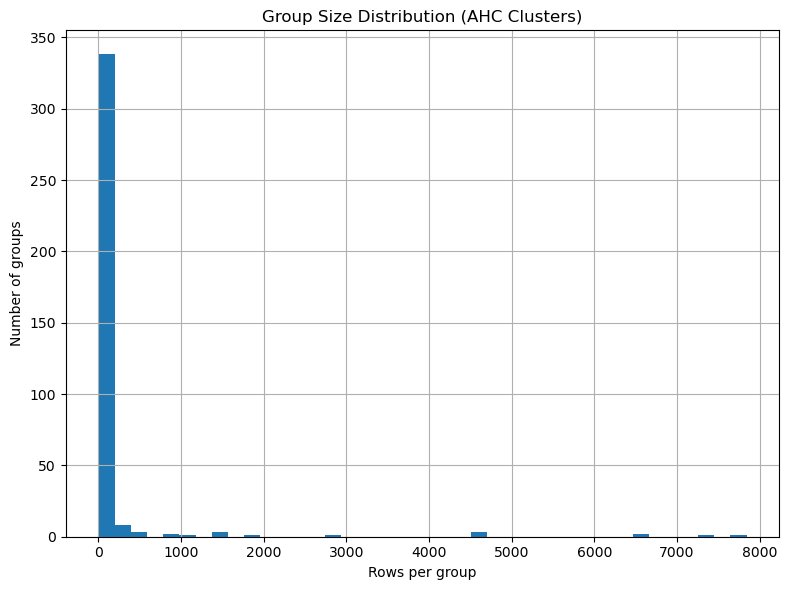

In [14]:
# --- Group summary statistics ---
group_counts = df_cleaned['ahc_cluster'].value_counts()
n_rows = len(df_cleaned)
n_groups = group_counts.shape[0]
group_summary = group_counts.describe()

# --- Print summary ---
print(f"✅ Final number of samples: {n_rows}")
print(f"✅ Final number of spatiotemporal groups: {n_groups}")

print("\n📊 Group Size Summary:")
print(group_summary)

print("\n🔎 Top 5 smallest groups:")
print(group_counts.sort_values().head())

print("\n🔎 Top 5 largest groups:")
print(group_counts.sort_values(ascending=False).head())

# --- Visualize distribution ---
plt.figure(figsize=(8, 6))
group_counts.hist(bins=40)
plt.xlabel("Rows per group")
plt.ylabel("Number of groups")
plt.title("Group Size Distribution (AHC Clusters)")
plt.tight_layout()
plt.show()


In [16]:
df_cleaned["ahc_cluster"].unique()

array([2010002, 2011001, 2015008, 2014000, 2015001, 2016006, 2017004,
       2018001, 2018004, 2019031, 2014035, 2015027, 2015011, 2012008,
       2013025, 2014011, 2012022, 2009001, 2010004, 2012005, 2019006,
       2014008, 2016012, 2016001, 2017026, 2018029, 2014001, 2015004,
       2016002, 2011004, 2010001, 2013013, 2009007, 2011018, 2009002,
       2005002, 2006006, 2008006, 2013004, 2015028, 2013005, 2013019,
       2014025, 2017028, 2016026, 2014030, 2015030, 2016025, 2008005,
       2010010, 2006003, 2008010, 2013014, 2013015, 2014021, 2015026,
       2014013, 2011021, 2013022, 2014003, 2014027, 2017024, 2015017,
       2017029, 2018031, 2014018, 2010011, 2018006, 2013009, 2015010,
       2016024, 2017003, 2018008, 2015022, 2016020, 2014020, 2015000,
       2012015, 2012018, 2017030, 2013003, 2011012, 2017006, 2012019,
       2013023, 2014036, 2011002, 2013002, 2014004, 2012010, 2017016,
       2018033, 2016019, 2018003, 2013026, 2019019, 2010014, 2014014,
       2011010, 2011

In [18]:
functions.summarize_dataframe(X_encoded)

| variable                                                              | dtype   |   count |   pct_complete |   n_unique |
|-----------------------------------------------------------------------|---------|---------|----------------|------------|
| Treatment_Category_Control                                            | float64 |   69430 |          100   |          2 |
| Tillage.type_plough                                                   | float64 |   69430 |          100   |          2 |
| Tillage.type_Rotary                                                   | float64 |   69430 |          100   |          2 |
| Tillage.type_Rotary tillage                                           | float64 |   69430 |          100   |          2 |
| Tillage.type_Tillage                                                  | float64 |   69430 |          100   |          2 |
| Tillage.type_ZT                                                       | float64 |   69430 |          100   |          2 |
| Tillag

Define Training and testing set (prepare for agony)

##### Testing and training split defined by AHC groups. 

In [ ]:
# Step 0: Setup
group_array = np.array(combined_groups, dtype=int)  # Shape: (n_obs,)
total_obs = len(group_array)
target_test_obs = int(total_obs * 0.15)

# Step 1: Create DataFrame to count obs per group
group_df = pd.DataFrame({'group': group_array})
group_counts = group_df.value_counts().reset_index(name='count')

# Step 2: Sort groups by recency (descending)
group_counts = group_counts.sort_values(by='group', ascending=False).reset_index(drop=True)

# Step 3: Accumulate groups until target test size reached
group_counts['cumulative_obs'] = group_counts['count'].cumsum()
test_groups = group_counts[group_counts['cumulative_obs'] <= target_test_obs]['group'].values

# If we undershoot a bit, add the next group to reach 15%
if group_counts['cumulative_obs'].iloc[len(test_groups)] < target_test_obs:
    test_groups = np.append(test_groups, group_counts['group'].iloc[len(test_groups)])

# Step 4: Create masks
test_mask = np.isin(group_array, test_groups)
trainval_mask = ~test_mask

# Step 5: Apply to split X and y
X_test = X_encoded.iloc[test_mask]
y_test = y.iloc[test_mask]
groups_test = group_array[test_mask]

X_trainval = X_encoded.iloc[trainval_mask]
y_trainval = y.iloc[trainval_mask]
groups_trainval = group_array[trainval_mask]

In [ ]:
# Define the seed for reproducibility
SEED = 42
np.random.seed(SEED)

#Drop the 'latitude and longitude' and columns from X_encoded
X_encoded = X_encoded.drop(columns=["lat", "lon", "Conversion.for.latitude", "Conversion.for.longitude"])


X_trainval, X_test, y_trainval, y_test, groups_trainval, groups_test = train_test_split(
    X_encoded,
    y,
    combined_groups,
    test_size=0.2,
    random_state=SEED,
    stratify=None  # Remove or set to None if group balance is poor
)

print(f"Train/Validation size: {X_trainval.shape[0]}")
print(f"Holdout test size:     {X_test.shape[0]}")


Train/Validation size: 55544
Holdout test size:     13886


In [ ]:
# 🌲 BLOCK 5: XGBoost Regressor + Random Search + GroupKFold
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = GroupKFold(n_splits=10)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    missing=np.nan,
    n_jobs=os.cpu_count() - 1,
    random_state=SEED
)

param_dist = {
    "n_estimators": [100, 250, 500],
    "max_depth": [4, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_trainval, y_trainval, groups=groups_trainval),
    verbose=1,
    n_jobs=-1,
    random_state=SEED
)



search.fit(X_trainval, y_trainval)
best_model = search.best_estimator_

Fitting 10 folds for each of 20 candidates, totalling 200 fits


Final model running

Final model trained in 0.07 minutes.
Holdout Test Set Evaluation Metrics:
  MAE : 0.7883
  RMSE: 1.1356
  R²  : 0.7073


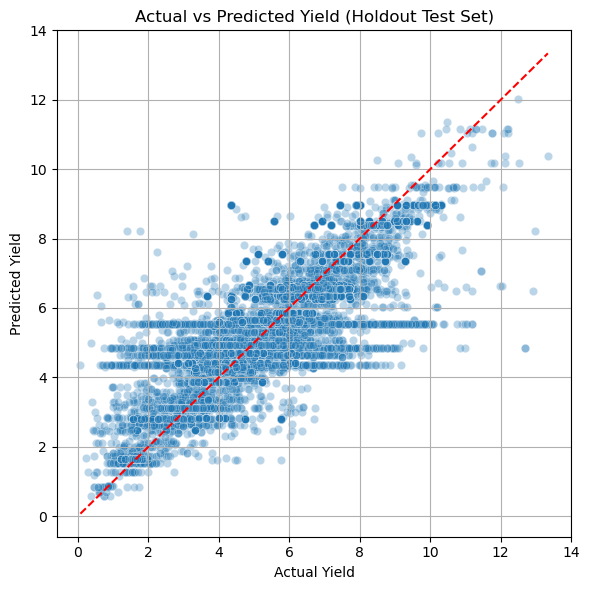

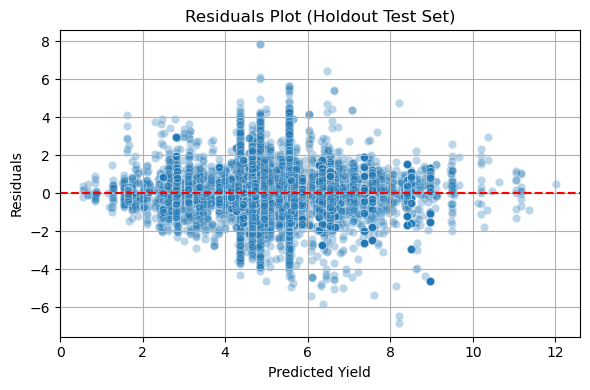

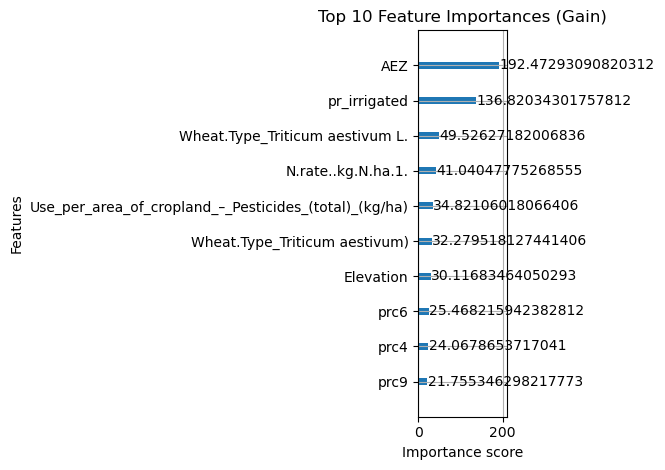

/tmp/ipykernel_40750/1929559830.py:66: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


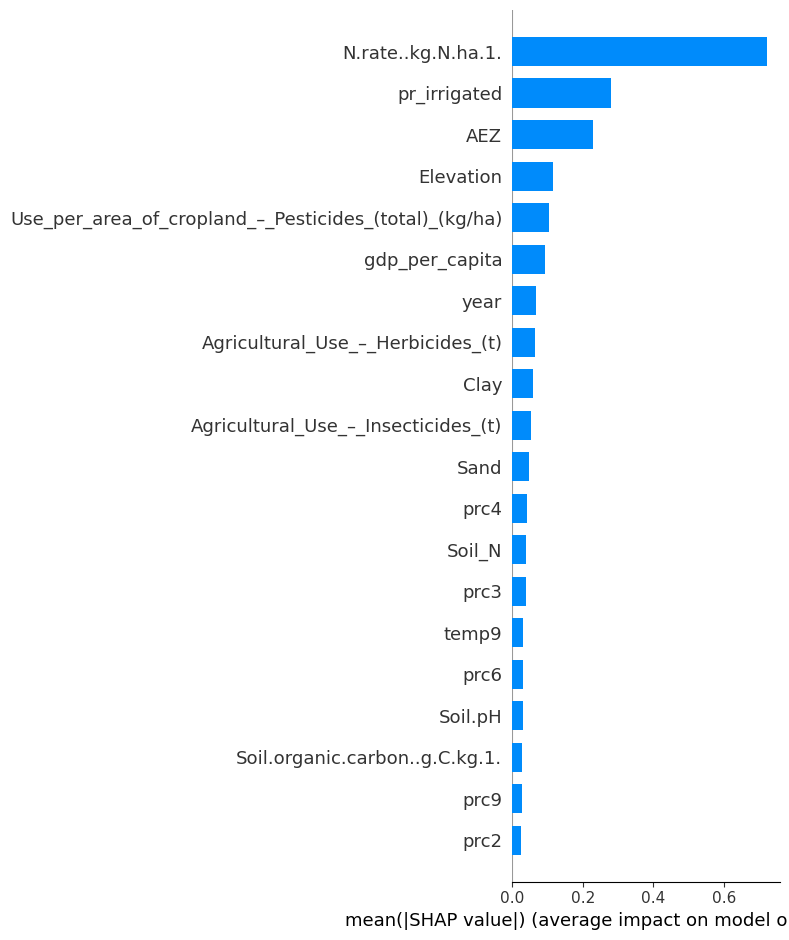

/tmp/ipykernel_40750/1929559830.py:69: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


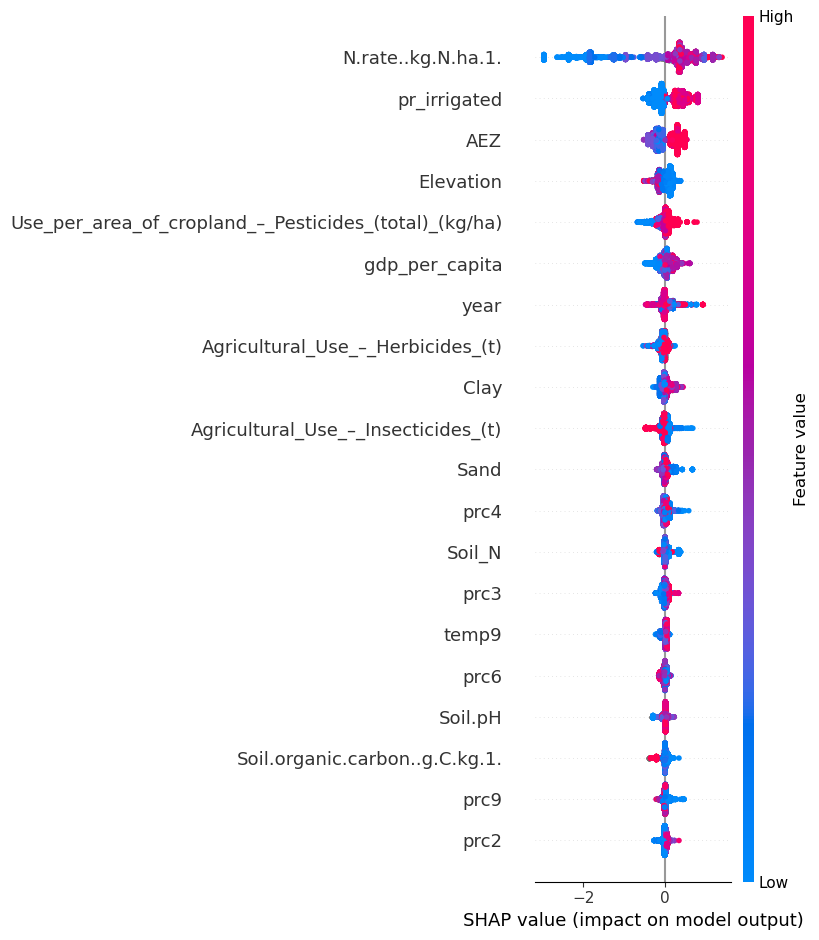

In [ ]:
# Use best parameters from random search
best_params = search.best_params_

# Build final model
best_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    tree_method="hist",
    missing=np.nan,
    n_jobs=os.cpu_count() - 1,
    random_state=0
)

# Train on full training+validation set
start_time = time.time()
best_model.fit(X_trainval, y_trainval)
print(f"Final model trained in {(time.time() - start_time)/60:.2f} minutes.")

# Predict on holdout test set
y_pred = best_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Holdout Test Set Evaluation Metrics:")
print(f"  MAE : {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²  : {r2:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals Plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance (XGBoost native)
xgb.plot_importance(best_model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances (Gain)")
plt.tight_layout()
plt.show()

# SHAP Explanation (on test data or a sample subset)
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# SHAP Summary: Bar Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# SHAP Summary: Beeswarm Plot
shap.summary_plot(shap_values, X_test)

